# k-Means Clustering

**Name:** Abdulaziz Aloufi  
**Student ID:** C00266252  
**Module:** Data Science & Machine Learning 2  

## Overview
This notebook implements k-Means clustering using a dataset about AI and student performance.

Unlike classification, k-Means is an **unsupervised learning** algorithm. This means it does not use a target label during training. Instead, it groups similar data points into clusters based on their features.

In this notebook I will:
- load and inspect the dataset
- prepare the data for clustering
- encode categorical columns
- scale the features
- use the elbow method to choose a value for `k`
- train a k-Means model
- analyse the clusters
- compare the clusters with the known performance categories

In [1]:
# =====================================================
# k-Means Clustering
# Name: Abdulaziz Aloufi
# Student ID: C00266252
# =====================================================

# importing the libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# just setting a nicer style for the plots
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## 1. Load the dataset

For this notebook I am using the same dataset about AI and student performance.

I chose to reuse it here because:
- it has a good mix of academic and AI-related features
- it is suitable for grouping students into clusters
- it helps compare supervised and unsupervised methods on the same dataset

In [2]:
# loading the dataset
df = pd.read_csv("../data/ai_impact_student_performance_dataset.csv")

# first look at the data
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [3]:
# filling missing values in categorical columns
df["ai_tools_used"] = df["ai_tools_used"].fillna("Unknown")
df["ai_usage_purpose"] = df["ai_usage_purpose"].fillna("Unknown")

# checking again
print(df.isnull().sum())
print("\nTotal missing values after fixing:", df.isnull().sum().sum())

student_id                         0
age                                0
gender                             0
grade_level                        0
study_hours_per_day                0
uses_ai                            0
ai_usage_time_minutes              0
ai_tools_used                      0
ai_usage_purpose                   0
ai_dependency_score                0
ai_generated_content_percentage    0
ai_prompts_per_week                0
ai_ethics_score                    0
last_exam_score                    0
assignment_scores_avg              0
attendance_percentage              0
concept_understanding_score        0
study_consistency_index            0
improvement_rate                   0
sleep_hours                        0
social_media_hours                 0
tutoring_hours                     0
class_participation_score          0
final_score                        0
passed                             0
performance_category               0
dtype: int64

Total missing values aft

In [4]:
# keeping the real category only for later comparison
true_labels = df["performance_category"]

# features for clustering
X = df.drop(columns=["student_id", "performance_category", "passed", "final_score"])

print("Feature shape:", X.shape)
X.head()

Feature shape: (8000, 22)


,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
0,20,Female,1st Year,2.5,1,170,Unknown,Exam Prep,10,29,...,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6
1,17,Male,12th,3.4,1,123,Unknown,Notes,4,14,...,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6
2,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,82,...,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3
3,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,74,...,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2
4,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,83,...,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2


In [5]:
# making a copy so the original stays safe
X_encoded = X.copy()

# finding categorical columns
cat_cols = X_encoded.select_dtypes(include=["object"]).columns
print("Categorical columns:", list(cat_cols))

Categorical columns: ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']


In [6]:
# encoding categorical columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

# quick check
X_encoded.head()

,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,...,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
0,20,0,3,2.5,1,170,5,2,10,29,...,29,40.9,98.8,4,9.0,8.1,7.2,1.5,4.6,6
1,17,1,2,3.4,1,123,5,4,4,14,...,60,87.2,89.3,8,8.5,13.8,7.6,5.1,2.7,6
2,24,1,5,0.8,0,35,3,1,8,82,...,98,77.1,50.8,7,2.1,39.1,5.7,0.2,4.0,3
3,21,0,2,4.4,0,45,1,4,3,74,...,67,86.4,52.1,5,6.7,25.2,8.2,4.2,2.9,2
4,18,2,5,3.5,1,21,1,0,2,83,...,40,69.4,40.7,5,5.4,2.7,8.7,0.2,2.9,2


In [7]:
# scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (8000, 22)


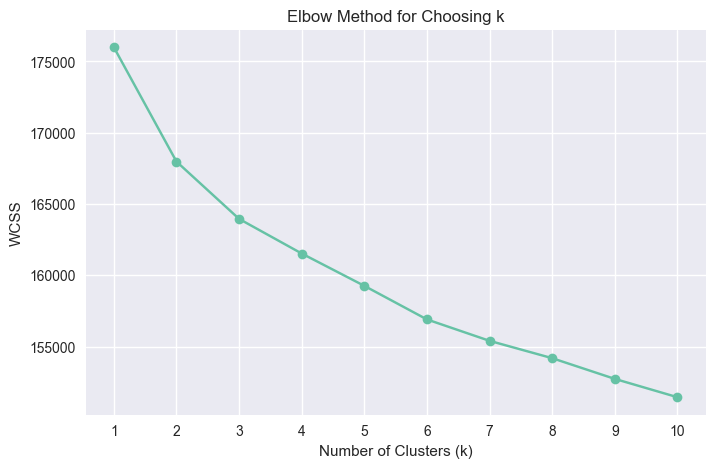

In [8]:
# using the elbow method
wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# plotting the elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [9]:
# training the final k-means model
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# adding cluster labels to the dataframe
df["cluster"] = clusters

# first look
df[["performance_category", "cluster"]].head()

,performance_category,cluster
0,Low,0
1,Medium,0
2,Medium,2
3,Medium,2
4,Low,1


cluster
2    2872
1    2619
0    2509
Name: count, dtype: int64


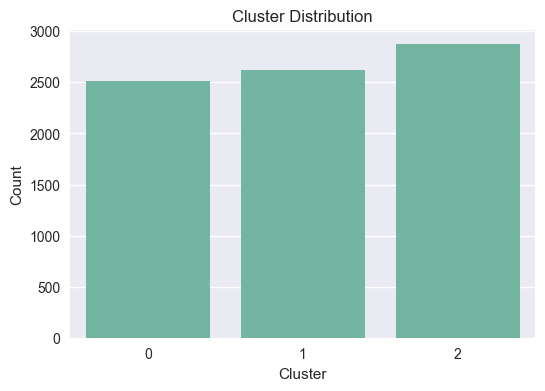

In [10]:
# checking how many rows are in each cluster
print(df["cluster"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="cluster", data=df)
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [11]:
# comparing clusters with the real performance categories
cluster_vs_performance = pd.crosstab(df["cluster"], df["performance_category"])
cluster_vs_performance

performance_category,High,Low,Medium
cluster,,,
0,246,756,1507
1,229,869,1521
2,278,917,1677


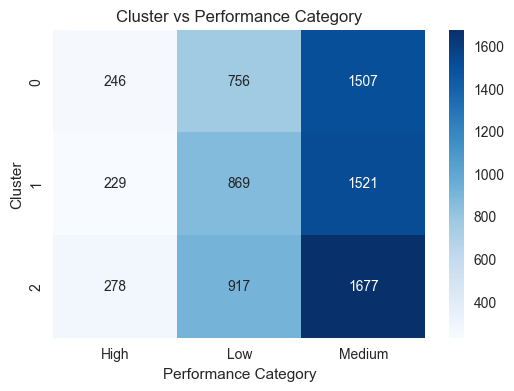

In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(cluster_vs_performance, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster vs Performance Category")
plt.xlabel("Performance Category")
plt.ylabel("Cluster")
plt.show()

In [13]:
# reducing the data to 2 dimensions just for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# making a plotting dataframe
plot_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "cluster": df["cluster"].astype(str),
    "performance_category": df["performance_category"]
})

plot_df.head()

,PCA1,PCA2,cluster,performance_category
0,-0.354530,-2.349937,0,Low
1,-0.506041,-0.750240,0,Medium
2,1.235089,0.049392,2,Medium
3,0.888210,0.631148,2,Medium
4,1.348027,0.110213,1,Low


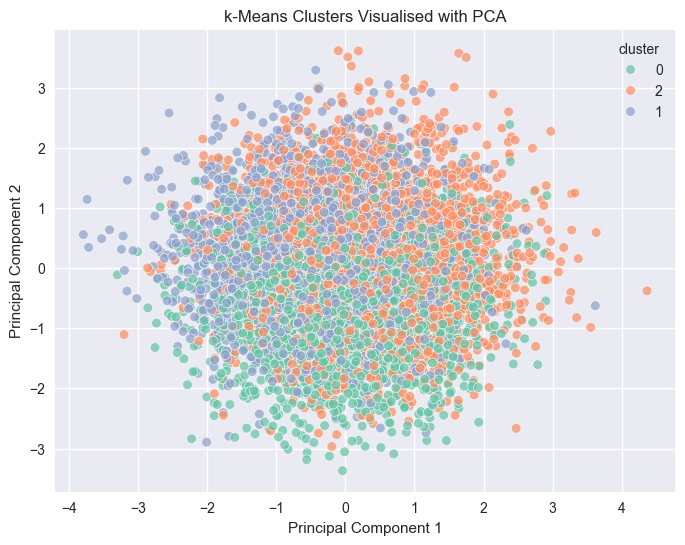

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PCA1", y="PCA2", hue="cluster", alpha=0.7)
plt.title("k-Means Clusters Visualised with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

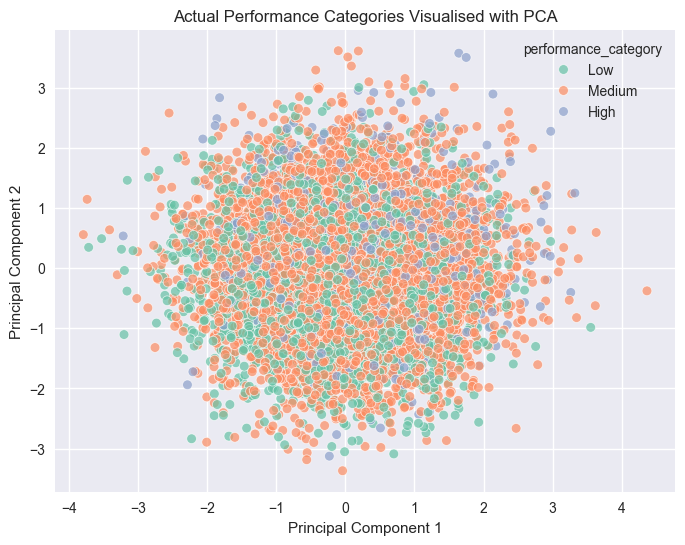

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PCA1", y="PCA2", hue="performance_category", alpha=0.7)
plt.title("Actual Performance Categories Visualised with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [16]:
# looking at average numeric values inside each cluster
cluster_summary = df.groupby("cluster").mean(numeric_only=True)
cluster_summary

,student_id,age,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,...,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed
cluster,,,,,,,,,,,,,,,,,,,,,
0,4005.534077,18.72778,3.370506,1.0,86.521722,5.441212,50.505779,59.039857,5.525309,61.011558,...,70.107931,5.578318,5.485054,10.914986,6.495815,2.838900,2.489279,5.363491,57.277003,0.894380
1,4065.733486,19.22604,3.184078,1.0,90.686522,5.626193,49.139366,60.113020,5.389843,58.223368,...,70.021535,5.378771,5.606567,9.564948,6.460596,3.225048,2.565979,5.467736,56.334402,0.886598
2,3936.615251,18.94046,3.307730,0.0,89.598886,5.478412,50.503134,58.951602,5.501393,59.347145,...,69.474130,5.499652,5.461699,9.952054,6.442166,2.965042,2.514345,5.546657,56.841260,0.887187


## 9. Conclusion

In this notebook I implemented k-Means clustering using a dataset about AI and student performance.

### Summary of work completed
- loaded and cleaned the dataset
- filled missing values in categorical columns using `"Unknown"`
- removed columns not suitable for clustering
- encoded categorical columns
- scaled the features
- used the elbow method to inspect possible values of `k`
- selected `k = 3` as a reasonable clustering solution
- trained a k-Means model
- assigned cluster labels to each student
- checked cluster sizes
- compared the clusters with the real performance categories
- visualised the clusters using PCA
- examined the average numeric values within each cluster

### Results
The elbow method suggested that the strongest improvement happened in the early values of `k`, and `k = 3` was chosen as a reasonable solution.

The cluster sizes were fairly balanced:
- Cluster 0: 2509
- Cluster 1: 2619
- Cluster 2: 2872

When I compared the clusters with the real `performance_category` labels, I found that all three clusters were still dominated by the `Medium` group. This means the clusters did not strongly match the labelled performance categories.

The PCA plots also showed a large amount of overlap between the clusters and between the real performance categories.

One interesting result from the cluster summary is that Cluster 0 and Cluster 1 had `uses_ai = 1.0`, while Cluster 2 had `uses_ai = 0.0`. This suggests that one of the strongest natural splits in the dataset may be whether students use AI or not, rather than their final performance category.

### Reflection
This notebook showed that k-Means can still be useful even when the clusters do not perfectly match known labels. In this case, the algorithm seems to have captured natural behavioural differences in the students, especially around AI usage, rather than directly reproducing the performance classes.